# Configuring the json file

In [ ]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the Cifra-10 Dataset


In [ ]:
from tensorflow.keras.datasets import cifar10
!ls

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Forma imaginilor de antrenament (x_train):", x_train.shape)
print("Forma etichetelor de antrenament (y_train):", y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Forma imaginilor de antrenament (x_train): (50000, 32, 32, 3)
Forma etichetelor de antrenament (y_train): (50000, 1)


# Data processing



Importing the libraries

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split

Normalization

In [ ]:
x_train_scaled = x_train / 255.0
x_test_scaled = x_test / 255.0

In [ ]:
from tensorflow.keras.utils import to_categorical

# CIFAR-10 are 10 clase în total
numar_clase = 10

# Transformăm y_train și y_test din numere întregi în vectori binari
y_train_categoric = to_categorical(y_train, numar_clase)
y_test_categoric = to_categorical(y_test, numar_clase)

print("Forma nouă a etichetelor de antrenament:", y_train_categoric.shape)
# Rezultatul așteptat: (50000, 10) în loc de (50000, 1)

Forma nouă a etichetelor de antrenament: (50000, 10)


Importing ResNet50

In [ ]:
from tensorflow.keras import Sequential, models, layers
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from google.colab import files
from tensorflow.keras.preprocessing import image

In [ ]:
convolutional_base = ResNet50(weights='imagenet', include_top= False, input_shape = (256,256,3))
convolutional_base.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
model = models.Sequential()# creaza un schelet gol pe care
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))# Creste dimensiunea imaginilor de la 32x32 la 128x128
model.add(convolutional_base)# Incarca modelul preantrenat ResNET-50
model.add(layers.Flatten())# Transforma iesirea de la modelul ResNET intr-un vector
model.add(layers.BatchNormalization())# Normalizeaza iesirile ca sa aiba media 0 si deviatia standard 1
model.add(layers.Dense(128, activation = 'relu'))# Layer cu 128 de neuroni, lasa sa treaca doar valori pozitive
model.add(layers.Dropout(0.5))# Ingheata temporar in mod aleator jumatate din neouroni
model.add(layers.BatchNormalization())
model.add(layers.Dense(64,activation ='relu'))# Layer cu 64 de neuroni
model.add(layers.Dropout(0.5))#
model.add(layers.BatchNormalization())
model.add(layers.Dense(numar_clase, activation = 'softmax'))# layer cu  10 neuroni, outputul va contine valori cu suma egala cu 1

In [ ]:
# 1. Definim Callback-ul pentru salvarea celui mai bun model
checkpoint_callback = ModelCheckpoint(
    filepath='cel_mai_bun_model.keras', # Numele fișierului în care se salvează
    monitor='val_loss',                 # Ne uităm la eroarea de validare
    save_best_only=True,                # Salvează doar dacă modelul este mai bun decât cel anterior
    mode='min',                         # Vrem ca eroarea (loss-ul) să fie minimă
    verbose=1                           # Afișează un mesaj când salvează modelul
)

In [ ]:
# 2. Definim Callback-ul pentru oprirea timpurie (Early Stopping)
early_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,                         # Dacă timp de 5 epoci la rând val_loss nu scade, oprește antrenarea
    restore_best_weights=True,          # La final, modelul din memorie revine automat la cele mai bune greutăți
    verbose=1
)

In [ ]:
model.compile(optimizer = optimizers.RMSprop(learning_rate= 2e-5), loss='categorical_crossentropy', metrics=['acc'])

In [ ]:
history = model.fit(x_train_scaled, y_train_categoric, validation_split=0.1, batch_size=64, epochs=10,callbacks=[checkpoint_callback, early_stop_callback])

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - acc: 0.3579 - loss: 1.9687
Epoch 1: val_loss improved from None to 2.17381, saving model to cel_mai_bun_model.keras

Epoch 1: finished saving model to cel_mai_bun_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 595s 760ms/step - acc: 0.4974 - loss: 1.5481 - val_acc: 0.2170 - val_loss: 2.1738
Epoch 2/10
 63/704 ━━━━━━━━━━━━━━━━━━━━ 7:43 723ms/step - acc: 0.7231 - loss: 0.9467

KeyboardInterrupt: 

In [ ]:
h = history

# Plot pentru loss
plt.plot(h.history['loss'],label= 'Train loss')
plt.plot(h.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

# Plot pentru accuritate
plt.plot(h.history['acc'],label= 'Train acc')
plt.plot(h.history['val_acc'], label='Validation acc')
plt.legend()
plt.show()

NameError: name 'history' is not defined

In [ ]:
def prezice_imagine_incarcata(model_antrenat):
    print("Te rog să încarci o imagine de pe dispozitivul tău:")
    uploaded = files.upload() # Deschide fereastra de upload

    for fn in uploaded.keys():
        path = fn
        print(f"\nSe procesează imaginea '{fn}'...")

        # 1. Încărcăm și redimensionăm imaginea la 32x32
        img = image.load_img(path, target_size=(32, 32))

        # Afișăm imaginea redimensionată ca să vedem cum arată
        plt.imshow(img)
        plt.axis('off')
        plt.show()

        # 2. Transformare în array
        img_array = image.img_to_array(img)

        # 3. Scalarea
        img_array = img_array / 255.0

        # 4. Adăugăm dimensiunea de batch modelul așteaptă [batch_size, width, height, channels]
        img_batch = np.expand_dims(img_array, axis=0)

        # 5. Facem predicția
        predictii = model_antrenat.predict(img_batch)

        # Extragem indexul cu cea mai mare probabilitate (argmax)
        clasa_prezisa_idx = np.argmax(predictii[0])
        probabilitate = np.max(predictii[0]) * 100

        # Traducem indexul în numele clasei
        nume_clasa = cifar10_classes[clasa_prezisa_idx]

        print(f"👉 Rezultat: Modelul spune că aceasta este un(o) **{nume_clasa.upper()}** (Siguranță: {probabilitate:.2f}%)")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/cel_mai_bun_model.keras')

In [ ]:
cifar10_classes = ['avion', 'automobil', 'pasăre', 'pisică', 'cerb',
                   'câine', 'broască', 'cal', 'navă', 'camion']

Te rog să încarci o imagine de pe dispozitivul tău:


Saving avion.jfif to avion.jfif

Se procesează imaginea 'avion.jfif'...


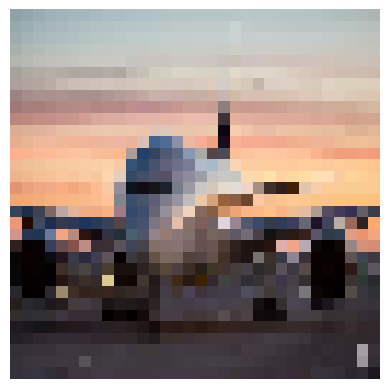

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
👉 Rezultat: Modelul spune că aceasta este un(o) **AVION** (Siguranță: 57.04%)


In [ ]:
prezice_imagine_incarcata(model)